# ScienceQA Visual Challenge: Starter Notebook

This notebook provides a starting point for the ScienceQA Visual Multiple-Choice Challenge. It is based on the provided baseline solution, but has been adapted to be more of a general-purpose starter.

**Objective:** Build a model that can answer visual multiple-choice questions based on scientific diagrams and text.

**Baseline Model:** `HuggingFaceTB/SmolVLM-500M-Instruct` (~500 M params)
**Fine-Tuning:** QLoRA (4-bit NF4)
**Scoring:** Multiple-choice log-likelihood

---

In [1]:
#Link google drive with collab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#── 0. Install libraries ──────────────────────────────────────────
#Run this cell to install the necessary Python packages.
!pip install -q transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 75.0 MB/s eta 0:00:00


In [14]:
# ── 1. Imports & Configuration ───────────────────────────────────────────────
import os
import json
import random
from pathlib import Path
from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model

import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

import re
from tqdm.auto import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
# Adjust these paths to match your local environment
DATA_DIR   = Path("/content/drive/MyDrive")

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# ── Basic Settings ───────────────────────────────────────────────────────────
IMG_SIZE        = 384

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. Load and Preprocess Data

In [6]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# The 'choices' column is a JSON string, so we parse it
for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
# train_df.head(2)
test_df.head(1)

Train: 3,109 | Val: 1,048 | Test: 1,008


,id,image_path,question,choices,num_choices,hint,lecture,task,grade,subject,topic,category,skill
0,test_01750,images/test/test_01750.png,"Based on clues in the text, why would farmers ...",[The cats were thought to be visiting goddesse...,4,Read the text about cats.\nCats are among the ...,"Informational texts include many facts, exampl...",closed choice,grade5,language science,reading-comprehension,Informational texts: level 1,Read passages about animals


In [7]:
#Observe Answer Distribution
distribution = train_df['answer'].value_counts(normalize=True).sort_index()

print("--- Training Label Distribution ---")
print(distribution)


distribution = val_df['answer'].value_counts(normalize=True).sort_index()

print("--- Eval Label Distribution ---")
print(distribution)



--- Training Label Distribution ---
answer
0    0.361531
1    0.330653
2    0.237054
3    0.065616
4    0.005146
Name: proportion, dtype: float64
--- Eval Label Distribution ---
answer
0    0.331107
1    0.354962
2    0.235687
3    0.071565
4    0.006679
Name: proportion, dtype: float64


In [8]:
# ── 2b. Prompt Engineering ───────────────────────────────────────────────────
CHOICE_LETTERS = "ABCDEFGHIJ"

def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
    """
    Builds the text prompt for the Vision Language Model.
    The <image> token is required for the model to process the image.
    """
    context_parts = []
    lecture = row.get("lecture", "")
    hint    = row.get("hint", "")
    if pd.notna(lecture) and str(lecture).strip():
        context_parts.append(str(lecture).strip())
    if pd.notna(hint) and str(hint).strip():
        context_parts.append(str(hint).strip())
    context_str = "\n".join(context_parts)

    choices = row["choices"]
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )

    prompt = "<image>\n"
    if context_str:
        prompt += f"Context:\n{context_str}\n\n"
    prompt += f"Question: {row['question']}\n"
    prompt += f"Choices:\n{choices_str}\n"
    prompt += "Answer:"

    if include_answer:
        answer_idx = int(row['answer'])
        prompt += f" {CHOICE_LETTERS[answer_idx]}"

    return prompt

# Display an example prompt
print(build_prompt(train_df.iloc[0], include_answer=True))


<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always successful

In [9]:
# # ── 2b. Prompt Engineering ───────────────────────────────────────────────────
# CHOICE_LETTERS = "ABCDEFGHIJ"

# def compress_text(text: str, max_words: int = 35) -> str:
#     """
#     Light compression:
#     - removes extra whitespace
#     - truncates to keep signal, not full text
#     """
#     if not text:
#         return ""

#     text = str(text).strip()
#     words = text.split()

#     if len(words) <= max_words:
#         return text

#     return " ".join(words[:max_words]) + "..."


# def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
#     """
#     Builds prompt with lightly compressed lecture/hint.
#     """

#     context_parts = []

#     # ── Lecture (safe null handling + compression) ──
#     lecture = row.get("lecture", None)
#     if pd.notna(lecture) and str(lecture).strip():
#         compressed_lecture = compress_text(str(lecture), max_words=40)
#         context_parts.append(f"Lecture: {compressed_lecture}")

#     # ── Hint (safe null handling + compression) ──
#     hint = row.get("hint", None)
#     if pd.notna(hint) and str(hint).strip():
#         compressed_hint = compress_text(str(hint), max_words=25)
#         context_parts.append(f"Hint: {compressed_hint}")

#     context_str = "\n".join(context_parts)

#     # ── Choices (your existing logic) ──
#     choices = row["choices"]
#     choices_str = "\n".join(
#         f"  {CHOICE_LETTERS[i]}. {extract_keyphrase(c)}"
#         for i, c in enumerate(choices)
#     )

#     # ── Prompt assembly ──
#     prompt = "<image>\n"
#     if context_str:
#       prompt += f"{context_str}\n\n"


#     prompt += f"Question: {row['question']}\n"
#     prompt += f"Choices:\n{choices_str}\n"


#     prompt += "Answer:"

#     if include_answer:
#         answer_idx = int(row['answer'])
#         prompt += f" {CHOICE_LETTERS[answer_idx]}"

#     return prompt


# # Example
# print(build_prompt(train_df.iloc[0], include_answer=True))

In [10]:
# ── 2c. PyTorch Dataset ───────────────────────────────────────────────────────



class ScienceQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_dir: Path, img_size: int = 512, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.df)


    # Update your Dataset's _load_image:
    def _load_image(self, rel_path: str) -> Image.Image:
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        return img

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])

        if self.is_train:
            return {
                "image":  img,
                "text":   build_prompt(row, include_answer=True),
                "answer": int(row["answer"]),
            }
        else:
            return {
                "image":   img,
                "text":    build_prompt(row, include_answer=False),
                "choices": row["choices"],
                "answer":  int(row["answer"]) if "answer" in row else -1,
            }

train_ds = ScienceQADataset(train_df, DATA_DIR, img_size=IMG_SIZE, is_train=True)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, img_size=IMG_SIZE, is_train=False)
test_ds  = ScienceQADataset(test_df,  DATA_DIR, img_size=IMG_SIZE, is_train=False)

print(f"Datasets created: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")


Datasets created: train=3109, val=1048, test=1008


In [11]:
# from torchvision import transforms

# # Conservative Augmentation for Science Diagrams
# train_transforms = transforms.Compose([
#     # Slight jitter to handle different lighting/contrast in scans
#     transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
#     # Very slight rotation (text must stay horizontal-ish)
#     transforms.RandomRotation(degrees=5),
#     # Perspective helps the model handle photos of textbook pages
#     transforms.RandomPerspective(distortion_scale=0.05, p=0.3),
#     # We convert to tensor for the transform, then back to PIL for the processor
#     transforms.ToTensor(),
#     transforms.ToPILImage()
# ])

In [12]:
# class ScienceQADataset(Dataset):
#     def __init__(self, df: pd.DataFrame, data_dir: Path, processor=None, model=None, is_train: bool = True,transform=None, **kwargs):
#         self.df = df.reset_index(drop=True)
#         self.data_dir = data_dir
#         self.is_train = is_train
#         self.transform = transform # Store the transforms here

#         # AUTOMATION: If captions don't exist, generate them NOW
#         if "caption" not in self.df.columns and model is not None and processor is not None:
#             self._auto_generate_captions(model, processor)

#     # ── THE MISSING PIECE ───────────────────────────────────────────────────
#     def __len__(self) -> int:
#         return len(self.df)
#     # ────────────────────────────────────────────────────────────────────────

#     def _auto_generate_captions(self, model, processor):
#         print(f"--- [SmartDataset] Generating Text-Bridge for {'Train' if self.is_train else 'Eval'} ---")
#         model.eval()
#         all_captions = []
#         batch_size = 4

#         for i in tqdm(range(0, len(self.df), batch_size)):
#             batch = self.df.iloc[i:i+batch_size]
#             images = [Image.open(self.data_dir / p).convert("RGB") for p in batch["image_path"]]
#             prompts = ["<image>\nDescribe this science diagram or image in detail:"] * len(images)

#             inputs = processor(text=prompts, images=images, return_tensors="pt", padding=True).to(model.device)
#             with torch.inference_mode():
#                 generated_ids = model.generate(**inputs, max_new_tokens=80, do_sample=False)

#             decoded = processor.batch_decode(generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#             all_captions.extend([t.strip() for t in decoded])

#         self.df["caption"] = all_captions

#     def _load_image(self, rel_path: str) -> Image.Image:
#       # Apply augmentation ONLY during training
#         if self.is_train and self.transform:
#             img = self.transform(img)
#         return Image.open(self.data_dir / rel_path).convert("RGB")

#     def __getitem__(self, idx: int) -> dict:
#         row = self.df.iloc[idx]
#         img = self._load_image(row["image_path"])
#         prompt_text = build_prompt(row, include_answer=self.is_train)

#         return {
#             "image":  img,
#             "text":   prompt_text,
#             "answer": int(row["answer"]) if "answer" in row else -1,
#         }
# train_ds = ScienceQADataset(
#     train_df,
#     DATA_DIR,
#     is_train=True,
#     transform=train_transforms  # Named argument!
# )
# val_ds   = ScienceQADataset(val_df,   DATA_DIR, img_size=IMG_SIZE, is_train=False)
# test_ds  = ScienceQADataset(test_df,  DATA_DIR, img_size=IMG_SIZE, is_train=False)

# print(f"Datasets created: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Found 81 Earth Science samples in validation set.
SAMPLE INDEX: 155
NATIVE IMAGE SIZE (WxH): (200, 202)
PROMPT PASSED TO MODEL:
<image>
Context:
Material that is carried by wind, water, or ice is called sediment. Sediment may be deposited, or laid down, in places such as deserts and the ocean floor. Different types of sediment are deposited in different environments. For example, sand may be deposited in a desert, and mud may be deposited at the bottom of the ocean.
The environment of an area can change over thousands of years. When the environment changes, the type of sediment that is deposited also changes. Over a long period of time, different layers of sediment can build up in the same area. These layers preserve a record of the environments that existed in that area in the past.
As many layers of sediment build up, they can be pressed together to form layers of sedimentary rock. A series of rock layers is called a rock sequence. You can observe the layers of a rock sequence to lea

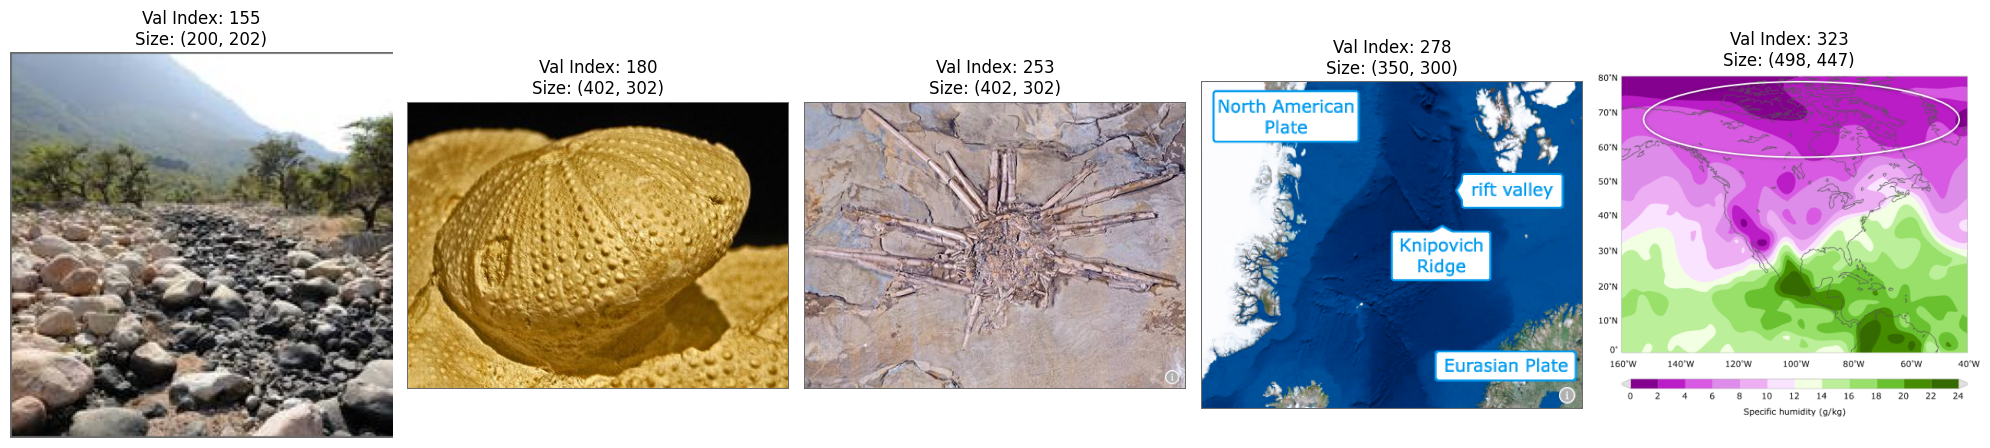

In [15]:
#Visualize a couple images and prompts

# 1. Filter the validation DataFrame for Earth Science questions
target_topic = 'earth-science'
earth_science_indices = val_df[val_df['topic'] == target_topic].index.tolist()

print(f"Found {len(earth_science_indices)} Earth Science samples in validation set.")

# 2. Display the first 5 samples
num_samples = min(5, len(earth_science_indices))
fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

for i, idx in enumerate(earth_science_indices[:num_samples]):
    # Pull directly from the PyTorch dataset to test your pipeline
    sample = val_ds[idx]
    img = sample["image"]
    prompt = sample["text"]

    # Handle single vs multiple subplot axes
    ax = axes[i] if num_samples > 1 else axes
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Val Index: {idx}\nSize: {img.size}")

    # Print the associated text and details below
    print(f"{"="*40}")
    print(f"SAMPLE INDEX: {idx}")
    print(f"NATIVE IMAGE SIZE (WxH): {img.size}")
    print(f"PROMPT PASSED TO MODEL:\n{prompt}")
    print(f"{"="*40}\n")

plt.tight_layout()
plt.show()

In [16]:
# # ── 2b. Prompt Engineering ───────────────────────────────────────────────────
# CHOICE_LETTERS = "ABCDEFGHIJ"

# def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
#     hint = str(row.get("hint", "")).strip()
#     lecture = str(row.get("lecture", "")).strip()

#     metadata_parts = []
#     for col in ["task", "grade", "subject", "topic", "category", "skill"]:
#         value = row.get(col, "")
#         if pd.notna(value) and str(value).strip():
#             metadata_parts.append(f"{col}: {str(value).strip()}")

#     choices = row["choices"]
#     choices_str = "\n".join(
#         f"{CHOICE_LETTERS[i]}. {str(c).strip()}"
#         for i, c in enumerate(choices)
#     )

#     prompt = "<image>\n"
#     prompt += "You are solving a multiple-choice question.\n"
#     prompt += "Use the image, passage, background information, and choices to select the best answer.\n"
#     prompt += "Respond with only the answer letter.\n\n"

#     if metadata_parts:
#         prompt += "Metadata:\n"
#         prompt += "\n".join(metadata_parts)
#         prompt += "\n\n"

#     if hint:
#         prompt += "Hint:\n"
#         prompt += hint
#         prompt += "\n\n"

#     if lecture:
#         prompt += "Background information:\n"
#         prompt += lecture
#         prompt += "\n\n"

#     prompt += "Question:\n"
#     prompt += str(row["question"]).strip()
#     prompt += "\n\n"

#     prompt += "Choices:\n"
#     prompt += choices_str
#     prompt += "\n\n"

#     prompt += "Answer:"

#     if include_answer:
#         prompt += f" {CHOICE_LETTERS[int(row['answer'])]}"

#     return prompt
# # Display an example prompt
# print(build_prompt(train_df.iloc[0], include_answer=True))


#Training


In [17]:
# ── 3. MODEL LOADING & PEFT INITIALIZATION ──────────────────────────────────
from transformers import BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# 1. Processor Setup
processor = AutoProcessor.from_pretrained(MODEL_ID,    size={"longest_edge": 512})
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# 2. Quantization Config (Reduces VRAM so the model fits on ONE GPU)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# 3. Load Model (Force to device 0 to avoid the "multiple devices" slow-down)
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    # Use "sdpa" (Scaled Dot Product Attention) - it's PyTorch's native
    # optimization that actually works on T4/Turing cards.
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
)

# 4. Training Preparations
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [18]:
# Quick check to see the distribution of prompt lengths
lengths = [len(processor.tokenizer.encode(build_prompt(row))) for _, row in train_df.iterrows()]
print(f"Max length: {max(lengths)}")
print(f"95th percentile: {pd.Series(lengths).quantile(0.95)}")

Max length: 684
95th percentile: 508.0


In [19]:
# Configure LoRA
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules="all-linear",
    # target_modules=[
    #     "q_proj", "v_proj", "o_proj", "k_proj", # Attention Layers
    #     "gate_proj", "up_proj", "down_proj"     # MLP / Feed-Forward Layers
    # ],
    task_type="CAUSAL_LM",
    use_dora=True
)
print(model)
# model.model.vision_model.requires_grad_(False)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (v_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (q_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (out_proj): Linear4bit(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear4bit(

In [20]:
# ── 4. COLLATOR WITH MASKING ────────────────────────────────────────────────
def collate_fn(batch):
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]

    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = inputs["input_ids"].clone()

    for i, text in enumerate(texts):
        # Mask everything before the actual answer
        prompt_part = text.split("Answer:")[0] + "Answer:"
        prompt_tokens = processor.tokenizer(prompt_part, add_special_tokens=False)["input_ids"]
        labels[i, :len(prompt_tokens)] = -100

    # Mask padding tokens
    labels[labels == processor.tokenizer.pad_token_id] = -100
    inputs["labels"] = labels
    return inputs

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    preds, labels = eval_pred


    labels = labels[:, 1:]
    mask = labels != -100
    correct = (preds[mask] == labels[mask]).sum()
    total = mask.sum()

    # Handle case where total might be zero to avoid division by zero
    acc = (correct / total).item() if total > 0 else 0.0
    return {"accuracy": acc}

def preprocess_logits_for_metrics(logits, labels):
    """
    We only care about the prediction for the very last token
    (the one that should be the Answer Letter).
    """
    if isinstance(logits, tuple):
        logits = logits[0]

    shift_labels = labels[..., 1:].contiguous()
    shift_logits = logits[..., :-1, :].contiguous()

    # Find the indices of the actual answer tokens
    # (The last token before the padding starts)
    argmax_logits = shift_logits.argmax(dim=-1)
    return argmax_logits

In [22]:
# ── 5. TRAINING ─────────────────────────────────────────────────────────────
train_ds = ScienceQADataset(train_df, DATA_DIR, is_train=True)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, is_train=False) # Eval uses labels for loss



training_args = TrainingArguments(
    output_dir="./smolvlm-ftChapter2_5epoch",
    per_device_train_batch_size=4,   # Keep at 2 for T4 VRAM safety
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=5,
    logging_steps=10,
    eval_steps=50,
    eval_strategy="steps",
    save_strategy="steps",
    # ── T4 SPECIFIC CHANGES ──────────────────────────────────────────────────
    fp16=True,                      # Use FP16 (T4 has native hardware support for this)
    bf16=False,                     # T4 DOES NOT support bfloat16 natively
    dataloader_num_workers=2,       # T4 instances usually only have 2 CPU cores; 4 can cause overhead
    dataloader_pin_memory=True,
    group_by_length=False,          # Set to False! This often causes loss spikes in VLMs
    gradient_checkpointing=True,    # Crucial to prevent OOM on T4's 16GB memory
    # ─────────────────────────────────────────────────────────────────────────
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    # ── Learning Schedule ────────────────────────────────────────────────────
    warmup_ratio=0.1,                   # 10% of training is "warmup"
    lr_scheduler_type="cosine",         # Smoother convergence
    weight_decay=0.01,
    # max_grad_norm=0.3,      # Added for stability at high LR
    report_to="none",
    optim="paged_adamw_8bit",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
)

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss,Accuracy
50,1.223500,1.080219,0.747108
100,0.623400,0.563717,0.866224
150,0.441400,0.400311,0.901139
200,0.264700,0.322555,0.919775
250,0.248500,0.289764,0.928016
300,0.264200,0.260176,0.931818
350,0.215000,0.244996,0.935635
400,0.162500,0.240149,0.938194
450,0.163700,0.232497,0.939090
500,0.177400,0.226909,0.940160


TrainOutput(global_step=975, training_loss=0.2918583692648472, metrics={'train_runtime': 2543.2497, 'train_samples_per_second': 6.112, 'train_steps_per_second': 0.383, 'total_flos': 2.047020456086861e+16, 'train_loss': 0.2918583692648472, 'epoch': 5.0})

In [23]:
from pathlib import Path

# Save final LoRA adapter + processor to Google Drive
SAVE_PATH = Path("/content/drive/MyDrive/") / training_args.output_dir.replace("./", "")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print(f"Saved adapter + processor to: {SAVE_PATH}")

Saved adapter + processor to: /content/drive/MyDrive/smolvlm-ftChapter2_5epoch


Starting Post-Training Analysis...


  0%|          | 0/131 [00:00<?, ?it/s]


--- Analysis Complete ---
Analyzed 1048 samples.
Overall Validation Accuracy: 71.09%

Sample Predictions (First 5):
                   Topic Pred_Str Label_Str  Is_Correct
0    literacy-in-science        B         A       False
1    literacy-in-science        A         B       False
2  reading-comprehension        D         D        True
3                biology        B         A       False
4                biology        B         E       False


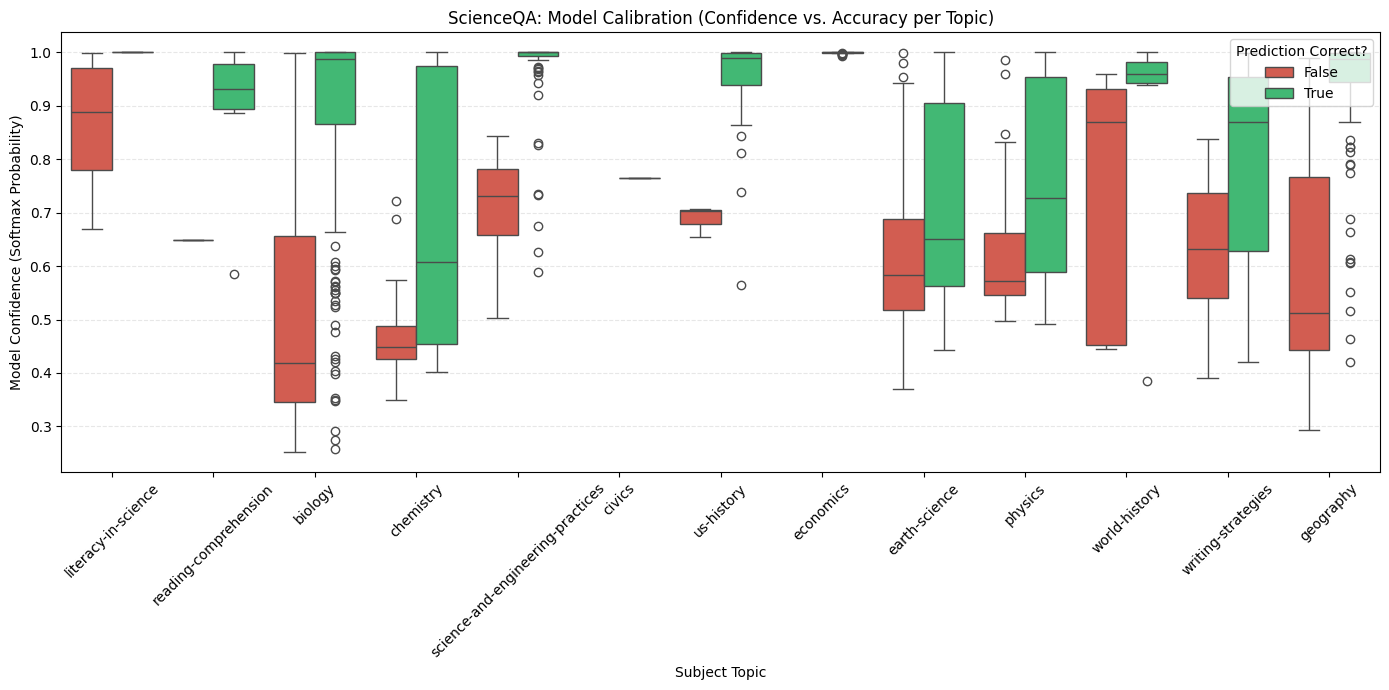


Subject Mastery Summary Table:
                                   Accuracy  Avg_Confidence  Sample_Count
Topic                                                                    
civics                             1.000000        0.765737             1
economics                          1.000000        0.999306            64
science-and-engineering-practices  0.956140        0.964999           114
us-history                         0.921053        0.927205            38
reading-comprehension              0.857143        0.853455             7
biology                            0.754579        0.798833           273
geography                          0.751938        0.843866           129
physics                            0.577465        0.691056           213
world-history                      0.545455        0.808095            11
earth-science                      0.543210        0.677008            81
chemistry                          0.527473        0.585734            91
writin

In [24]:
#Compute validation loss after training and display subplots and per-topic accuracy


val_ds   = ScienceQADataset(val_df,   DATA_DIR, is_train=True) # Eval uses labels for loss

def run_confidence_analysis_final(trainer, dataset, tokenizer):
    model = trainer.model
    model.eval()
    dataloader = trainer.get_eval_dataloader(dataset)
    results = []
    current_idx = 0

    # Pre-tokenize the trigger to find it in the sequence
    # Note: different tokenizers handle the leading space differently
    trigger_text = "Answer:"

    print("Starting Post-Training Analysis...")
    for batch in tqdm(dataloader):
        with torch.no_grad():
            inputs = {k: v.to(model.device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
            outputs = model(**inputs)
            logits = outputs.logits
            labels = batch["labels"].to(model.device)
            input_ids = inputs["input_ids"]

            for i in range(labels.size(0)):
                # 1. Get the full sequence of IDs (prioritizing labels where the answer lives)
                seq_ids = labels[i].cpu().numpy()
                # Replace padding with a dummy so we can decode
                clean_ids = [id if id != -100 else tokenizer.pad_token_id for id in seq_ids]

                # 2. Find the index of the "Answer:" token
                # We search the decoded list for the token that contains or follows "Answer"
                found_pos = -1
                for idx, tid in enumerate(clean_ids):
                    if tid == tokenizer.pad_token_id: continue
                    decoded_token = tokenizer.decode([tid])
                    if "Answer" in decoded_token:
                        found_pos = idx
                        break

                # 3. The 'Label' is typically 1 or 2 tokens AFTER "Answer" (depending on the colon and space)
                # We'll look for the first non-padding token AFTER the "Answer" position
                if found_pos != -1:
                    target_label_idx = -1
                    # Search ahead for the first letter (A, B, C...)
                    for search_idx in range(found_pos + 1, len(clean_ids)):
                        token_text = tokenizer.decode([clean_ids[search_idx]]).strip()
                        if token_text and token_text not in [":", ""]:
                            target_label_idx = search_idx
                            break

                    if target_label_idx != -1:
                        # Logic: Logits at [t] predict Label at [t+1]
                        pred_pos = target_label_idx - 1

                        target_logits = logits[i, pred_pos, :]
                        target_id = labels[i, target_label_idx].item()

                        probs = torch.softmax(target_logits, dim=-1)
                        conf, pred_id = torch.max(probs, dim=-1)

                        pred_str = tokenizer.decode(pred_id).strip()
                        label_str = tokenizer.decode(target_id).strip()

                        row = dataset.df.iloc[current_idx]
                        results.append({
                            "Topic": row.get('topic', 'Unknown'),
                            "Confidence": conf.item(),
                            "Is_Correct": pred_str.lower() == label_str.lower(),
                            "Pred_Str": pred_str,
                            "Label_Str": label_str
                        })

                current_idx += 1

    return pd.DataFrame(results)
# --- 1. Run Analysis ---
# Note: Using 'tokenizer' from your global environment
analysis_df = run_confidence_analysis_final(trainer, val_ds, processor.tokenizer)

# --- 2. Check Sanity & Display Summary ---
if not analysis_df.empty:
    overall_acc = analysis_df["Is_Correct"].mean()
    print(f"\n--- Analysis Complete ---")
    print(f"Analyzed {len(analysis_df)} samples.")
    print(f"Overall Validation Accuracy: {overall_acc:.2%}")

    print("\nSample Predictions (First 5):")
    print(analysis_df[['Topic', 'Pred_Str', 'Label_Str', 'Is_Correct']].head())

    # --- 3. Visualization: Confidence vs. Accuracy ---
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=analysis_df,
        x="Topic",
        y="Confidence",
        hue="Is_Correct",
        palette={True: "#2ecc71", False: "#e74c3c"}
    )
    plt.title("ScienceQA: Model Calibration (Confidence vs. Accuracy per Topic)")
    plt.ylabel("Model Confidence (Softmax Probability)")
    plt.xlabel("Subject Topic")
    plt.xticks(rotation=45)
    plt.legend(title="Prediction Correct?", loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. Subject Mastery Table ---
    summary = analysis_df.groupby("Topic").agg(
        Accuracy=("Is_Correct", "mean"),
        Avg_Confidence=("Confidence", "mean"),
        Sample_Count=("Topic", "count")
    ).sort_values("Accuracy", ascending=False)

    print("\nSubject Mastery Summary Table:")
    print(summary)
else:
    print("Error: Analysis DataFrame is empty. Check your validation dataset.")

In [25]:
# Quick downsampling check
min_count = train_df['answer'].value_counts().min()
print(min_count)


16


## 3. Model Loading and Inference Example

This section loads `HuggingFaceTB/SmolVLM-500M-Instruct` and runs a quick inference example on one validation sample.

#Inference

In [26]:
processor.tokenizer.padding_side = "left"

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token


model.eval()

def test_collate_fn(batch):
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    return inputs

BATCH_SIZE = 4

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=test_collate_fn,
)

def extract_answer_index(text):
    if text is None:
        return 0

    text = text.strip().upper()

    # Prefer explicit answer patterns
    match = re.search(r"ANSWER\s*[:\-]?\s*([A-J])\b", text)
    if match:
        return CHOICE_LETTERS.index(match.group(1))

    # Otherwise grab the first standalone A-J
    match = re.search(r"\b([A-J])\b", text)
    if match:
        return CHOICE_LETTERS.index(match.group(1))

    return 0


results = []
row_ptr = 0



for inputs in tqdm(test_loader):
    batch_size = inputs["input_ids"].shape[0]

    batch_ids = test_df.iloc[row_ptr:row_ptr + batch_size]["id"].tolist()
    row_ptr += batch_size

    inputs = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    # Decode only newly generated tokens, not the prompt
    prompt_len = inputs["input_ids"].shape[1]
    new_tokens = generated_ids[:, prompt_len:]

    decoded = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )

    for sample_id, text in zip(batch_ids, decoded):
        pred = extract_answer_index(text)
        print(f"[ID: {sample_id}] -> RAW: {repr(text)} | PRED: {CHOICE_LETTERS[pred]} ({pred})")
        results.append({
            "id": sample_id,
            "answer": pred,
        })


submission_df = pd.DataFrame(results)
submission_df.to_csv(DATA_DIR / "submission-5epochsChapter2_5epoch.csv", index=False)

submission_df.head()

  0%|          | 0/252 [00:00<?, ?it/s]

[ID: test_01750] -> RAW: ' B). The cats helped farmers keep grain from going bad.\n\nAnswer: B). The cats' | PRED: B (1)
[ID: test_00128] -> RAW: ' A) 0/4.\nAnswer: A.\n\nQuestion: What is the probability' | PRED: A (0)
[ID: test_02891] -> RAW: ' A\n\nQuestion: How many offspring will have a white ground spot?\nChoices:\n ' | PRED: A (0)
[ID: test_02425] -> RAW: ' D\n\nAnswer: D\n\nQuestion: What is the probability that a budgerigar' | PRED: D (3)
[ID: test_00930] -> RAW: ' B\n\nQuestion: What is the probability that a muskmelon plant produced by this cross' | PRED: B (1)
[ID: test_03725] -> RAW: ' A\n\nQuestion: What is the probability that a sheep produced by this cross will be heterozygous' | PRED: A (0)
[ID: test_00009] -> RAW: ' A\n\nQuestion: What is the expected ratio of offspring with a woolly fleece to offspring' | PRED: A (0)
[ID: test_02880] -> RAW: ' B\n\nAnswer: B)\n\nQuestion: Which of the following statements is true?\n' | PRED: B (1)
[ID: test_01208] -> RAW: ' B\n\nQues

,id,answer
0,test_01750,1
1,test_00128,0
2,test_02891,0
3,test_02425,3
4,test_00930,1


In [27]:
# processor.tokenizer.padding_side = "left"

# if processor.tokenizer.pad_token is None:
#     processor.tokenizer.pad_token = processor.tokenizer.eos_token

# model.eval()
# model.config.use_cache = True

# CHOICE_LETTERS = "ABCDEFGHIJ"


# def test_collate_fn(batch):
#     images = [item["image"] for item in batch]
#     texts = [item["text"] for item in batch]

#     inputs = processor(
#         text=texts,
#         images=images,
#         return_tensors="pt",
#         padding=True,
#     )

#     return inputs


# def get_choice_token_ids(tokenizer, max_choices=10):
#     """
#     Gets token IDs for answer letters A, B, C...
#     Since your training prompt uses 'Answer: A', we try the leading-space form first.
#     """
#     token_ids = []

#     for letter in CHOICE_LETTERS[:max_choices]:
#         ids = tokenizer(f" {letter}", add_special_tokens=False)["input_ids"]

#         # Fallback if leading-space version is not one token
#         if len(ids) != 1:
#             ids = tokenizer(letter, add_special_tokens=False)["input_ids"]

#         if len(ids) != 1:
#             raise ValueError(
#                 f"Choice {letter} did not tokenize to one token. Got token ids: {ids}"
#             )

#         token_ids.append(ids[0])

#     return token_ids


# choice_token_ids = get_choice_token_ids(
#     processor.tokenizer,
#     max_choices=len(CHOICE_LETTERS)
# )

# choice_token_ids_tensor = torch.tensor(
#     choice_token_ids,
#     device=model.device
# )

# print("Answer token mapping:")
# for i, tok_id in enumerate(choice_token_ids):
#     print(
#         f"{CHOICE_LETTERS[i]} -> token_id={tok_id}, "
#         f"decoded={repr(processor.tokenizer.decode([tok_id]))}"
#     )


# BATCH_SIZE = 4

# test_loader = DataLoader(
#     test_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     collate_fn=test_collate_fn,
# )

# print(f"\nStarting inference on {len(test_ds):,} test examples...")
# print(f"Batch size: {BATCH_SIZE}")
# print(f"Total batches: {len(test_loader):,}\n")


# results = []
# row_ptr = 0
# print_every = 25   # change to 1 if you want every batch printed

# progress_bar = tqdm(test_loader, desc="Running logit-scored inference")

# for batch_idx, inputs in enumerate(progress_bar, start=1):
#     batch_size = inputs["input_ids"].shape[0]

#     batch_rows = test_df.iloc[row_ptr:row_ptr + batch_size]
#     row_ptr += batch_size

#     inputs = {
#         k: v.to(model.device) if torch.is_tensor(v) else v
#         for k, v in inputs.items()
#     }

#     with torch.inference_mode():
#         outputs = model(**inputs)
#         logits = outputs.logits

#     # With left padding, the actual prompt ends at the final sequence position.
#     # Logits at this position predict the next token after "Answer:".
#     seq_len = inputs["input_ids"].shape[1]

#     last_token_pos = torch.full(
#         size=(batch_size,),
#         fill_value=seq_len - 1,
#         device=model.device,
#         dtype=torch.long,
#     )

#     batch_indices = torch.arange(batch_size, device=model.device)
#     next_token_logits = logits[batch_indices, last_token_pos, :]

#     batch_debug = []

#     for i, (_, row) in enumerate(batch_rows.iterrows()):
#         if "num_choices" in row and pd.notna(row["num_choices"]):
#             num_choices = int(row["num_choices"])
#         else:
#             num_choices = len(row["choices"])

#         num_choices = min(num_choices, len(row["choices"]), len(CHOICE_LETTERS))

#         valid_choice_ids = choice_token_ids_tensor[:num_choices]
#         choice_logits = next_token_logits[i, valid_choice_ids]

#         pred = int(torch.argmax(choice_logits).item())

#         # Confidence/debug info
#         choice_probs = torch.softmax(choice_logits.float(), dim=-1)
#         confidence = float(choice_probs[pred].item())

#         pred_letter = CHOICE_LETTERS[pred]

#         results.append({
#             "id": row["id"],
#             "answer": pred,
#         })

#         batch_debug.append(
#             f"ID={row['id']} pred={pred_letter}({pred}) conf={confidence:.4f}"
#         )

#     # tqdm progress bar text
#     progress_bar.set_postfix({
#         "processed": row_ptr,
#         "last_pred": pred_letter,
#         "last_conf": f"{confidence:.3f}",
#     })

#     # Print progress every N batches and first/last batch
#     if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == len(test_loader):
#         print(
#             f"\nBatch {batch_idx}/{len(test_loader)} | "
#             f"Processed {row_ptr}/{len(test_ds)} examples"
#         )
#         for msg in batch_debug:
#             print("  " + msg)


# submission_df = pd.DataFrame(results)
# submission_df.to_csv(DATA_DIR / "submission-lora32645epochs.csv", index=False)
